# Critical Evaluation and Reproduction of Machine Learning-Based Website Phishing Detection

**Selected paper:** *Towards Benchmark Datasets for Machine Learning Based Website Phishing Detection: An Experimental Study*  
**Project category:** Phishing Detection  
**Goal:** Reproduce and critically evaluate a machine-learning approach for detecting phishing websites.

This notebook includes:
- data loading and inspection
- missing value analysis
- duplicated row/feature analysis
- EDA
- feature engineering
- model training
- evaluation
- feature-group experiments
- redundancy analysis
- error analysis
- critical evaluation notes for the report

## 1. Imports and Configuration

In [1]:
import warnings
import zipfile
import shutil
import ast
warnings.filterwarnings("ignore")

from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score,
)

RANDOM_STATE = 42
DATA_PATH = Path("../data/dataset.csv")
TARGET_COLUMN = "status"

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 120)

## 2. Helper Functions

These functions keep the notebook clean and reduce duplicated code.

In [2]:
def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy of the dataframe with normalized column names."""
    cleaned = df.copy()
    cleaned.columns = (
        cleaned.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace(".", "_", regex=False)
    )
    return cleaned


def _extract_zip(data_dir: Path) -> None:
    """Extract the first zip found in data_dir, flattening the top-level folder."""
    zip_files = list(data_dir.glob("*.zip"))
    if not zip_files:
        return
    zip_path = zip_files[0]
    print(f"Extracting {zip_path.name} ...")
    extract_dir = data_dir / "_extracted"
    extract_dir.mkdir(exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(extract_dir)
    # Locate the single top-level folder produced by the zip
    tops = [p for p in extract_dir.iterdir() if p.is_dir()]
    root = tops[0] if tops else extract_dir
    # Move each item in root to data_dir (skip if already present)
    for item in root.iterdir():
        dest = data_dir / item.name
        if not dest.exists():
            shutil.move(str(item), str(dest))
    shutil.rmtree(extract_dir)
    # Rename dataset_B CSV to the expected filename
    raw_csv = data_dir / "dataset_B_05_2020.csv"
    if raw_csv.exists() and not (data_dir / "dataset.csv").exists():
        raw_csv.rename(data_dir / "dataset.csv")
    print("Extraction complete.")


def load_dataset(path: Path) -> pd.DataFrame:
    """Load the dataset CSV, extracting a zip first if the CSV is not yet present."""
    if not path.exists():
        _extract_zip(path.parent)
    if not path.exists():
        raise FileNotFoundError(
            f"Dataset not found at: {path}\n"
            "Place the dataset zip or CSV inside ../data/ and update DATA_PATH if needed."
        )
    return pd.read_csv(path)


def evaluate_predictions(y_true, y_pred, y_score=None) -> Dict[str, float]:
    """Calculate classification metrics for binary phishing detection."""
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        # F2 weights recall above precision: in phishing a missed attack (FN)
        # is costlier than a false alarm (FP), so recall deserves more weight.
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }
    if y_score is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    else:
        metrics["roc_auc"] = np.nan
    return metrics


def train_and_evaluate_model(
    model_name: str,
    model,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: np.ndarray,
    y_test: np.ndarray,
) -> Tuple[Dict[str, float], np.ndarray]:
    """Train one model and return metrics and predictions."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = None
    metrics = evaluate_predictions(y_test, y_pred, y_score)
    metrics["model"] = model_name
    return metrics, y_pred


def get_highly_correlated_features(
    X: pd.DataFrame,
    threshold: float = 0.95,
    method: str = "spearman",
) -> Tuple[pd.DataFrame, List[str]]:
    """Find highly correlated feature pairs and recommend features to drop."""
    corr = X.corr(method=method).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
        .sort_values("correlation", ascending=False)
    )
    high_pairs = pairs[pairs["correlation"] >= threshold]
    features_to_drop = high_pairs["feature_2"].unique().tolist()
    return high_pairs, features_to_drop

## 3. Data Loading

This section loads the dataset and gives a first look at its shape and content.

In [3]:
df_raw = load_dataset(DATA_PATH)

print("Raw dataset shape:", df_raw.shape)
df_raw.head()

Raw dataset shape: (11430, 89)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,nb_underscore,nb_tilde,nb_percent,nb_slash,nb_star,nb_colon,nb_comma,nb_semicolumn,nb_dollar,nb_space,nb_www,nb_com,nb_dslash,http_in_path,https_token,ratio_digits_url,ratio_digits_host,punycode,port,tld_in_path,tld_in_subdomain,abnormal_subdomain,nb_subdomains,prefix_suffix,random_domain,shortening_service,path_extension,nb_redirection,nb_external_redirection,length_words_raw,char_repeat,shortest_words_raw,shortest_word_host,shortest_word_path,longest_words_raw,longest_word_host,longest_word_path,avg_words_raw,avg_word_host,avg_word_path,phish_hints,domain_in_brand,brand_in_subdomain,brand_in_path,suspecious_tld,statistical_report,nb_hyperlinks,ratio_intHyperlinks,ratio_extHyperlinks,ratio_nullHyperlinks,nb_extCSS,ratio_intRedirection,ratio_extRedirection,ratio_intErrors,ratio_extErrors,login_form,external_favicon,links_in_tags,submit_email,ratio_intMedia,ratio_extMedia,sfh,iframe,popup_window,safe_anchor,onmouseover,right_clic,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,0,0,0,0,3,0,1,0,0,0,0,1,0,0,0,1,0.000000,0.0,0,0,0,0,0,3,0,0,0,0,0,0,4,4,3,3,3,11,11,6,5.750000,7.0,4.500000,0,0,0,0,0,0,17,0.529412,0.470588,0,0,0,0.875000,0,0.500000,0,0,80.000000,0,100.000000,0.000000,0,0,0,0.0,0,0,0,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,0,0,0,0,5,0,1,0,0,0,0,0,0,0,0,1,0.220779,0.0,0,0,0,0,0,1,0,0,0,0,1,0,4,4,2,19,2,32,19,32,15.750000,19.0,14.666667,0,0,0,0,0,0,30,0.966667,0.033333,0,0,0,0.000000,0,0.000000,0,0,100.000000,0,80.000000,20.000000,0,0,0,100.0,0,0,0,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,3,2,0,0,5,0,1,0,0,0,0,0,1,0,0,0,0.150794,0.0,0,0,0,1,0,3,1,0,0,0,1,0,12,2,2,3,2,17,13,17,8.250000,8.4,8.142857,0,0,0,0,0,0,4,1.000000,0.000000,0,0,0,0.000000,0,0.000000,0,0,100.000000,0,0.000000,0.000000,0,0,0,100.0,0,0,0,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,1,0.000000,0.0,0,0,0,0,0,2,0,0,0,0,1,0,1,0,5,5,0,5,5,0,5.000000,5.0,0.000000,0,0,0,0,0,0,149,0.973154,0.026846,0,0,0,0.250000,0,0.250000,0,0,100.000000,0,96.428571,3.571429,0,0,0,62.5,0,0,0,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,0,0,0,0,5,0,1,0,0,0,0,1,0,0,0,1,0.000000,0.0,0,0,0,0,0,2,0,0,0,0,1,0,6,3,3,3,4,11,7,11,6.333333,5.0,7.000000,0,0,0,0,0,0,102,0.470588,0.529412,0,0,0,0.537037,0,0.018519,1,0,76.470588,0,0.000000,100.000000,0,0,0,0.0,0,0,0,0,1,0,224,8175,8725,0,0,6,legitimate


## 4. Data Cleaning and Initial Inspection

We normalize column names so that coding is easier and less error-prone.

In [4]:
df = clean_column_names(df_raw)

print("Cleaned dataset shape:", df.shape)
print("First 20 columns:")
print(df.columns[:20].tolist())

df.head()

Cleaned dataset shape: (11430, 89)
First 20 columns:
['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar']


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,nb_underscore,nb_tilde,nb_percent,nb_slash,nb_star,nb_colon,nb_comma,nb_semicolumn,nb_dollar,nb_space,nb_www,nb_com,nb_dslash,http_in_path,https_token,ratio_digits_url,ratio_digits_host,punycode,port,tld_in_path,tld_in_subdomain,abnormal_subdomain,nb_subdomains,prefix_suffix,random_domain,shortening_service,path_extension,nb_redirection,nb_external_redirection,length_words_raw,char_repeat,shortest_words_raw,shortest_word_host,shortest_word_path,longest_words_raw,longest_word_host,longest_word_path,avg_words_raw,avg_word_host,avg_word_path,phish_hints,domain_in_brand,brand_in_subdomain,brand_in_path,suspecious_tld,statistical_report,nb_hyperlinks,ratio_inthyperlinks,ratio_exthyperlinks,ratio_nullhyperlinks,nb_extcss,ratio_intredirection,ratio_extredirection,ratio_interrors,ratio_exterrors,login_form,external_favicon,links_in_tags,submit_email,ratio_intmedia,ratio_extmedia,sfh,iframe,popup_window,safe_anchor,onmouseover,right_clic,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,0,0,0,0,3,0,1,0,0,0,0,1,0,0,0,1,0.000000,0.0,0,0,0,0,0,3,0,0,0,0,0,0,4,4,3,3,3,11,11,6,5.750000,7.0,4.500000,0,0,0,0,0,0,17,0.529412,0.470588,0,0,0,0.875000,0,0.500000,0,0,80.000000,0,100.000000,0.000000,0,0,0,0.0,0,0,0,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,0,0,0,0,5,0,1,0,0,0,0,0,0,0,0,1,0.220779,0.0,0,0,0,0,0,1,0,0,0,0,1,0,4,4,2,19,2,32,19,32,15.750000,19.0,14.666667,0,0,0,0,0,0,30,0.966667,0.033333,0,0,0,0.000000,0,0.000000,0,0,100.000000,0,80.000000,20.000000,0,0,0,100.0,0,0,0,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,3,2,0,0,5,0,1,0,0,0,0,0,1,0,0,0,0.150794,0.0,0,0,0,1,0,3,1,0,0,0,1,0,12,2,2,3,2,17,13,17,8.250000,8.4,8.142857,0,0,0,0,0,0,4,1.000000,0.000000,0,0,0,0.000000,0,0.000000,0,0,100.000000,0,0.000000,0.000000,0,0,0,100.0,0,0,0,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,1,0.000000,0.0,0,0,0,0,0,2,0,0,0,0,1,0,1,0,5,5,0,5,5,0,5.000000,5.0,0.000000,0,0,0,0,0,0,149,0.973154,0.026846,0,0,0,0.250000,0,0.250000,0,0,100.000000,0,96.428571,3.571429,0,0,0,62.5,0,0,0,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,0,0,0,0,5,0,1,0,0,0,0,1,0,0,0,1,0.000000,0.0,0,0,0,0,0,2,0,0,0,0,1,0,6,3,3,3,4,11,7,11,6.333333,5.0,7.000000,0,0,0,0,0,0,102,0.470588,0.529412,0,0,0,0.537037,0,0.018519,1,0,76.470588,0,0.000000,100.000000,0,0,0,0.0,0,0,0,0,1,0,224,8175,8725,0,0,6,legitimate


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  object 
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percent                  114

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
url,11430,11429,http://e710z0ear.du.r.appspot.com/c:/users/use...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
length_url,11430.0,NaN,NaN,NaN,61.126684,55.297318,12.0,33.0,47.0,71.0,1641.0
length_hostname,11430.0,NaN,NaN,NaN,21.090289,10.777171,4.0,15.0,19.0,24.0,214.0
ip,11430.0,NaN,NaN,NaN,0.150569,0.357644,0.0,0.0,0.0,0.0,1.0
nb_dots,11430.0,NaN,NaN,NaN,2.480752,1.369686,1.0,2.0,2.0,3.0,24.0
nb_hyphens,11430.0,NaN,NaN,NaN,0.99755,2.087087,0.0,0.0,0.0,1.0,43.0
nb_at,11430.0,NaN,NaN,NaN,0.022222,0.1555,0.0,0.0,0.0,0.0,4.0
nb_qm,11430.0,NaN,NaN,NaN,0.141207,0.364456,0.0,0.0,0.0,0.0,3.0
nb_and,11430.0,NaN,NaN,NaN,0.162292,0.821337,0.0,0.0,0.0,0.0,19.0
nb_or,11430.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Column and Index Analysis

Use this cell to inspect whether column names and the index make sense.  
For example, if the dataset contains a raw URL column, it should usually be treated as an identifier unless you intentionally extract new URL features from it.

In [7]:
print("Index type:", type(df.index))
print("Index name:", df.index.name)
print("Number of columns:", len(df.columns))
print("Column names:")
print(df.columns.tolist())

Index type: <class 'pandas.core.indexes.range.RangeIndex'>
Index name: None
Number of columns: 89
Column names:
['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com', 'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_redirection', 'nb_external_redirection', 'length_words_raw', 'char_repeat', 'shortest_words_raw', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand', 'brand_in_subdomain', 'brand_in_path', 'suspecious_tld', 'statistical_r

## 5. Target Column Analysis

The target column should represent whether a website is phishing or legitimate.

In [8]:
if TARGET_COLUMN not in df.columns:
    print(f"TARGET_COLUMN='{TARGET_COLUMN}' was not found.")
    print("Possible target-like columns:")
    possible_targets = [col for col in df.columns if col in ["status", "label", "class", "target", "result", "phishing"]]
    print(possible_targets)
    raise ValueError("Please update TARGET_COLUMN to the correct target column name.")

print("Target column:", TARGET_COLUMN)
df[TARGET_COLUMN].value_counts(dropna=False)

Target column: status


status
legitimate    5715
phishing      5715
Name: count, dtype: int64

In [9]:
y_raw = df[TARGET_COLUMN]

if y_raw.dtype == "object":
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_raw)
    print("Target mapping:")
    for original, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
        print(f"{original} -> {encoded}")
else:
    # Numeric target: ensure phishing = 1, legitimate = 0
    # Adjust if your dataset uses a different convention
    y = y_raw.to_numpy()
    label_encoder = None
    print("Numeric target detected.")
    print(pd.Series(y).value_counts())

Target mapping:
legitimate -> 0
phishing -> 1


## 6. Missing Value Analysis

Missing values are important because some phishing-related features, especially external-service features, may be unavailable in real systems.

In [10]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent,
})

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percent


In [11]:
missing_to_plot = missing_summary[missing_summary["missing_count"] > 0]

if missing_to_plot.empty:
    print("No missing values found.")
else:
    missing_to_plot["missing_percent"].plot(kind="bar", figsize=(12, 4))
    plt.title("Missing Values Percentage by Feature")
    plt.ylabel("Missing Percentage")
    plt.xlabel("Feature")
    plt.tight_layout()
    plt.show()

No missing values found.


## 7. Duplicated Rows and Duplicated Features

Duplicated rows may create data leakage if the same examples appear in both training and testing data.  
Duplicated features increase redundancy and reduce interpretability.

In [12]:
duplicate_rows = df.duplicated().sum()
print("Number of duplicated rows:", duplicate_rows)

if duplicate_rows > 0:
    df[df.duplicated()].head()

Number of duplicated rows: 0


In [13]:
duplicate_columns_mask = df.T.duplicated()
duplicate_columns = df.columns[duplicate_columns_mask].tolist()

print("Number of duplicated columns:", len(duplicate_columns))
print("Duplicated columns:", duplicate_columns)

Number of duplicated columns: 5
Duplicated columns: ['ratio_nullhyperlinks', 'ratio_intredirection', 'ratio_interrors', 'submit_email', 'sfh']


## 8. Prepare Features

We remove the target column and optional identifier columns such as raw URL strings.

In [14]:
X_full = df.drop(columns=[TARGET_COLUMN])

possible_identifier_cols = [
    "url", "domain", "website", "webpage", "link", "index"
]

identifier_cols = [col for col in possible_identifier_cols if col in X_full.columns]
print("Identifier-like columns found:", identifier_cols)

X_full = X_full.drop(columns=identifier_cols, errors="ignore")

# Keep numeric features for this baseline project.
# If you have categorical features, handle them with encoding.
numeric_features = X_full.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_full.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)

X = X_full[numeric_features].copy()

# Remove redundant and uninformative columns before modeling.
# 1. Constant (zero-variance) columns carry no signal and break correlation analysis.
constant_cols = [col for col in X.columns if X[col].nunique() <= 1]

# 2. Exact duplicate columns (detected in Section 7) store the same information twice.
duplicate_cols_in_X = [col for col in duplicate_columns if col in X.columns]

cols_to_remove = sorted(set(constant_cols) | set(duplicate_cols_in_X))
print("Constant columns removed:", constant_cols)
print("Duplicate columns removed:", duplicate_cols_in_X)

X = X.drop(columns=cols_to_remove, errors="ignore")
print("Final feature matrix shape:", X.shape)

Identifier-like columns found: ['url']
Numeric features: 87
Categorical features: []
Constant columns removed: ['nb_or', 'ratio_nullhyperlinks', 'ratio_intredirection', 'ratio_interrors', 'submit_email', 'sfh']
Duplicate columns removed: ['ratio_nullhyperlinks', 'ratio_intredirection', 'ratio_interrors', 'submit_email', 'sfh']
Final feature matrix shape: (11430, 81)


## 9. Class Balance Analysis

This checks whether the dataset is balanced.  
In real phishing detection, legitimate websites are usually much more common than phishing websites, so class balance must be interpreted carefully.

In [15]:
class_counts = pd.Series(y).value_counts().sort_index()
class_percent = pd.Series(y).value_counts(normalize=True).sort_index() * 100

class_balance = pd.DataFrame({
    "count": class_counts,
    "percent": class_percent.round(2),
})

class_balance

,count,percent
0,5715,50.0
1,5715,50.0


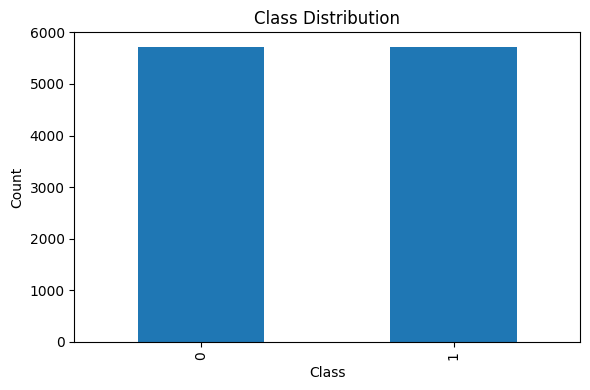

In [16]:
class_counts.plot(kind="bar", figsize=(6, 4))
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 10. Exploratory Data Analysis: Feature Distributions

This section compares feature values between phishing and legitimate classes.  
Select meaningful features after inspecting your real dataset columns.

Features selected for EDA (top |Spearman| correlation with target):
['google_index', 'nb_hyperlinks', 'page_rank', 'nb_www', 'ratio_digits_url', 'phish_hints', 'domain_in_title', 'web_traffic']


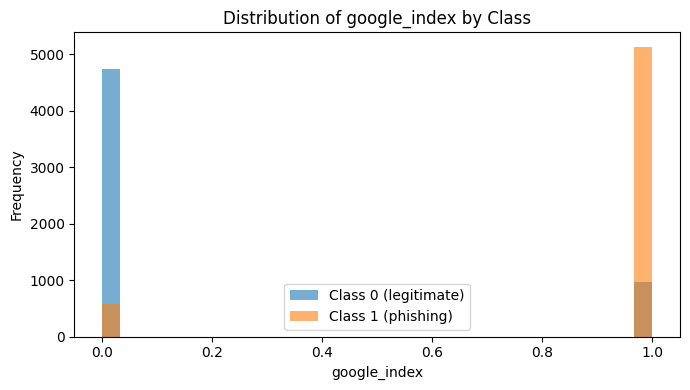

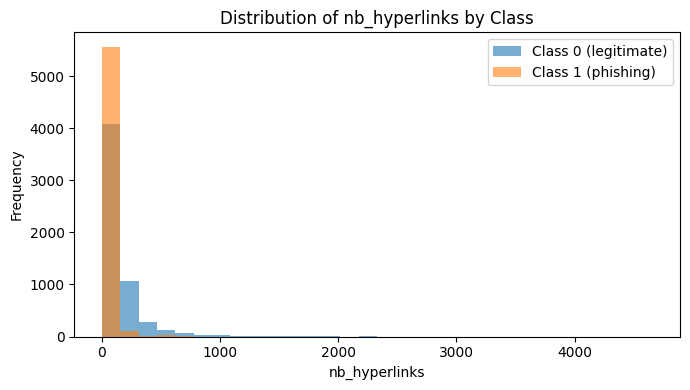

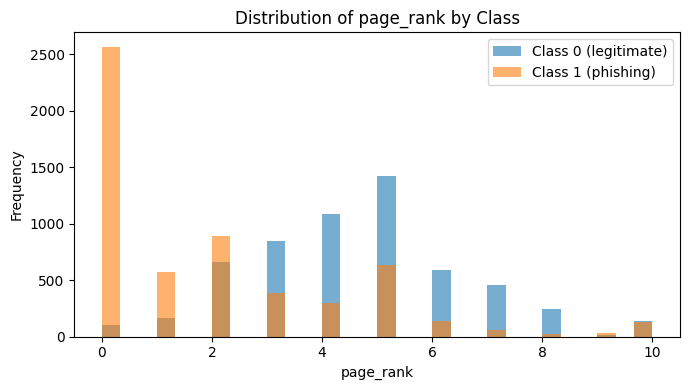

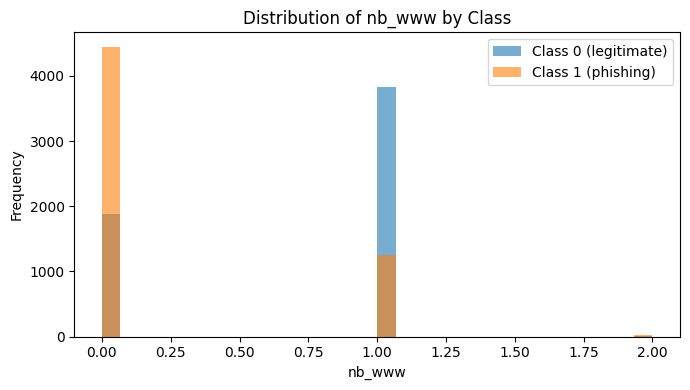

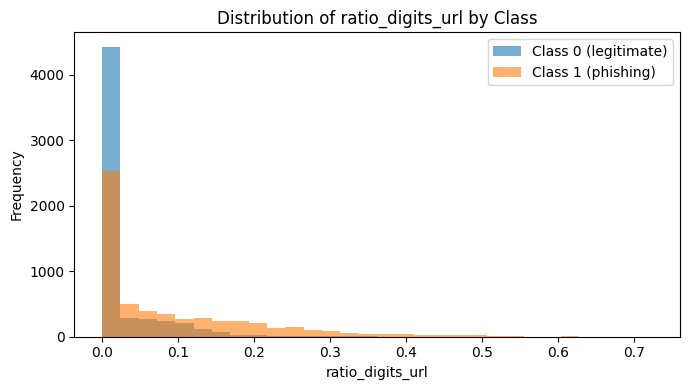

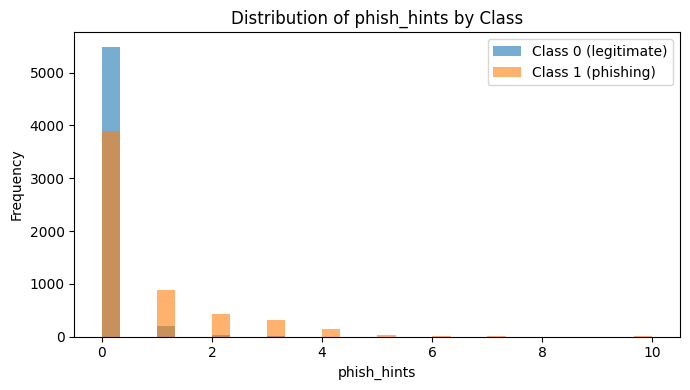

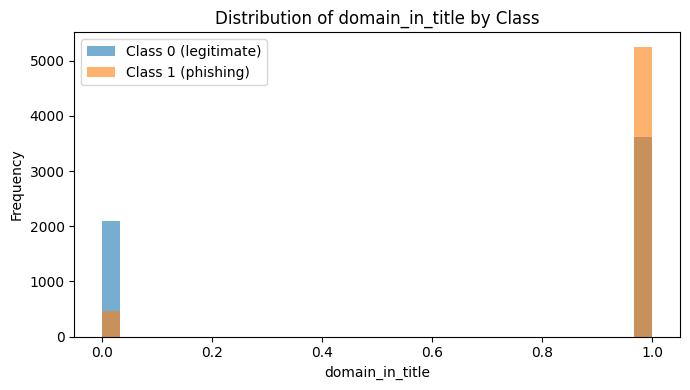

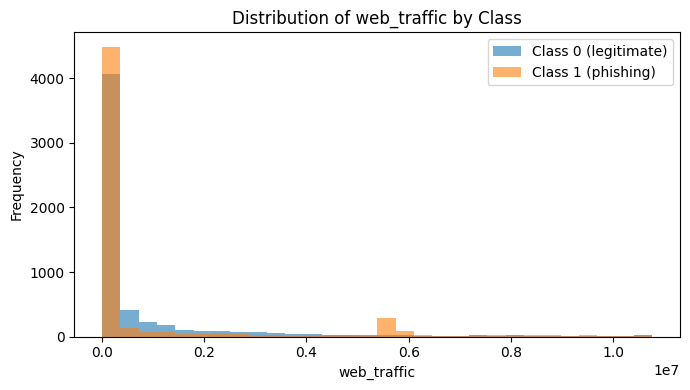

In [17]:
# Select the features most strongly associated with the target for EDA,
# instead of the first few columns (which are low-signal count features).
target_assoc = X.corrwith(pd.Series(y, index=X.index), method="spearman").abs()
eda_features = target_assoc.sort_values(ascending=False).head(8).index.tolist()
print("Features selected for EDA (top |Spearman| correlation with target):")
print(eda_features)

for feature in eda_features:
    class0 = X.loc[y == 0, feature]
    class1 = X.loc[y == 1, feature]

    # Use a shared range so constant-valued classes are not invisible
    x_min = min(class0.min(), class1.min())
    x_max = max(class0.max(), class1.max())

    # If both classes have the same single value, widen the range slightly
    if x_min == x_max:
        x_min -= 0.5
        x_max += 0.5

    plt.figure(figsize=(7, 4))
    plt.hist(class0, bins=30, range=(x_min, x_max), alpha=0.6, label="Class 0 (legitimate)")
    plt.hist(class1, bins=30, range=(x_min, x_max), alpha=0.6, label="Class 1 (phishing)")
    plt.title(f"Distribution of {feature} by Class")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 11. Outlier Analysis

Outliers may represent unusual URL structures, extremely long pages, or abnormal link behavior.

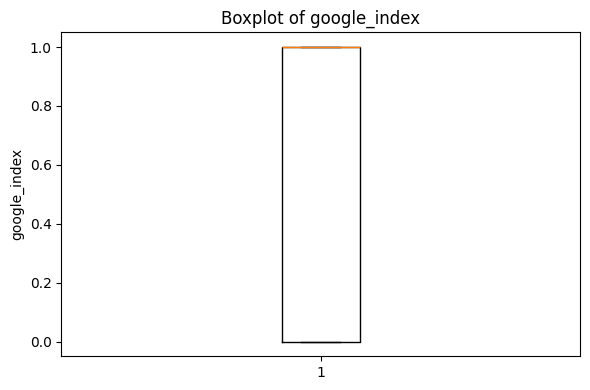

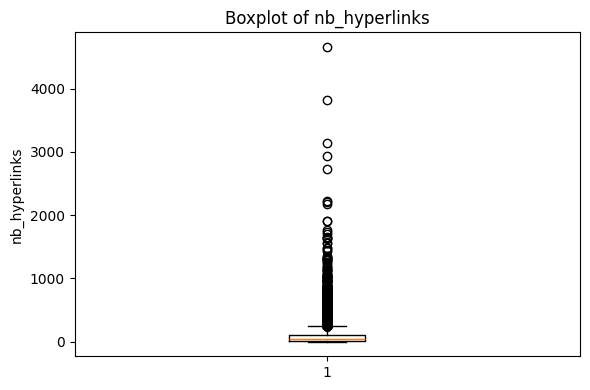

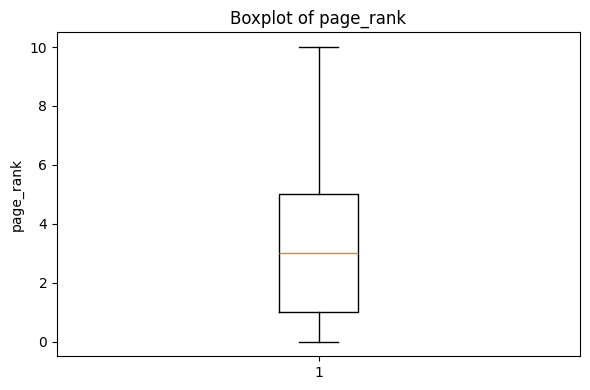

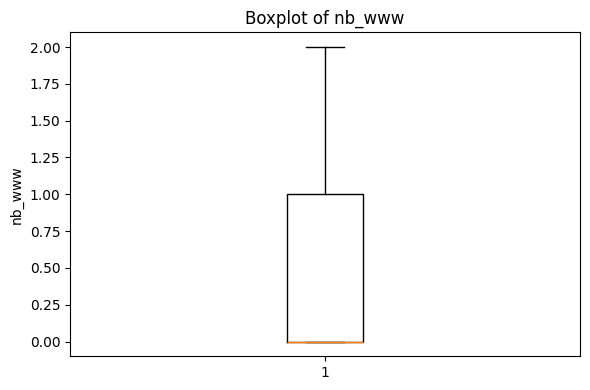

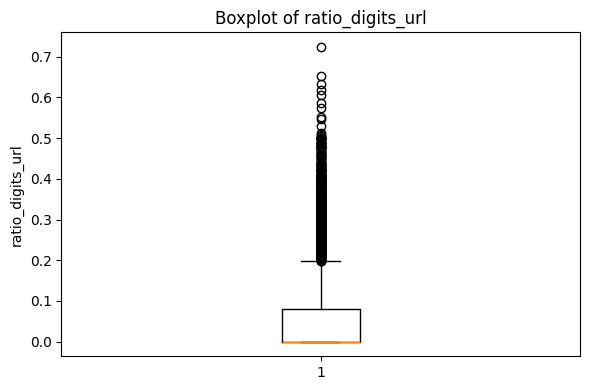

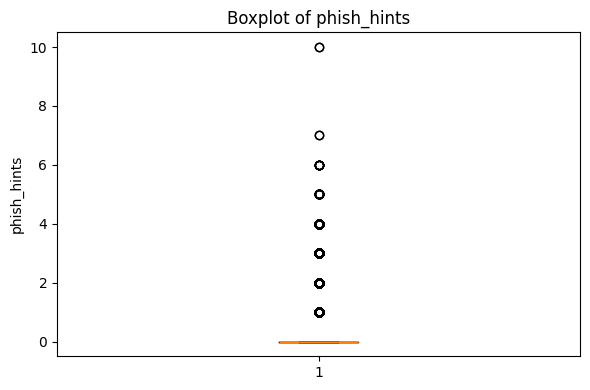

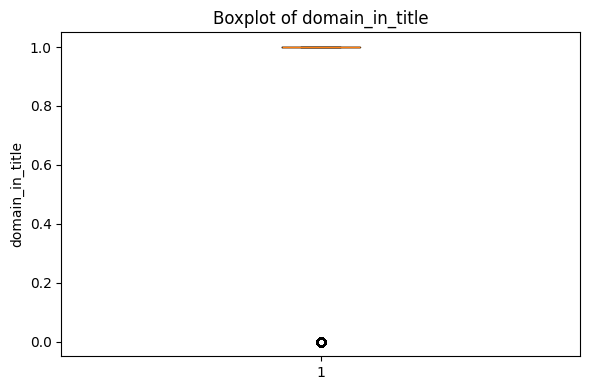

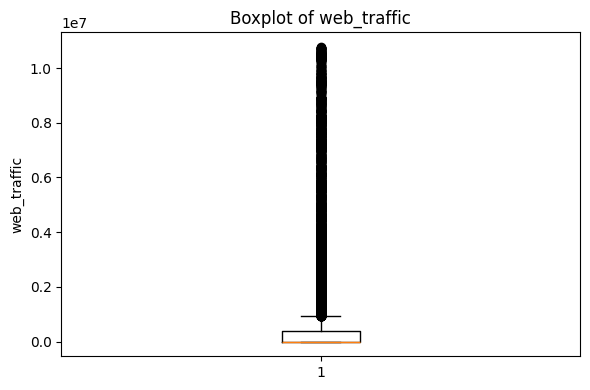

In [18]:
# Reuse the same high-signal features chosen for the distribution plots above.
outlier_features = eda_features

for feature in outlier_features:
    plt.figure(figsize=(6, 4))
    plt.boxplot(X[feature].dropna())
    plt.title(f"Boxplot of {feature}")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

## 12. Correlation and Redundancy Analysis

We use **Spearman correlation** because many phishing-detection features are binary, ordinal, count-based, or not normally distributed.  
Spearman correlation measures monotonic relationships and is more robust to outliers than Pearson correlation.

In [19]:
spearman_corr = X.corr(method="spearman").abs()

print("Correlation matrix shape:", spearman_corr.shape)
spearman_corr.iloc[:10, :10]

Correlation matrix shape: (81, 81)


,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,nb_underscore
length_url,1.000000,0.265952,0.460767,0.447577,0.499997,0.171076,0.452759,0.397332,0.467991,0.397640
length_hostname,0.265952,1.000000,0.140537,0.324128,0.134604,0.014400,0.078580,0.151429,0.097970,0.058594
ip,0.460767,0.140537,1.000000,0.283278,0.127176,0.066007,0.408002,0.485577,0.441848,0.251486
nb_dots,0.447577,0.324128,0.283278,1.000000,0.112334,0.202175,0.292637,0.306017,0.295019,0.211811
nb_hyphens,0.499997,0.134604,0.127176,0.112334,1.000000,0.041806,0.085752,0.104079,0.095536,0.020112
nb_at,0.171076,0.014400,0.066007,0.202175,0.041806,1.000000,0.236640,0.098641,0.247579,0.006737
nb_qm,0.452759,0.078580,0.408002,0.292637,0.085752,0.236640,1.000000,0.638647,0.916903,0.379070
nb_and,0.397332,0.151429,0.485577,0.306017,0.104079,0.098641,0.638647,1.000000,0.708838,0.427892
nb_eq,0.467991,0.097970,0.441848,0.295019,0.095536,0.247579,0.916903,0.708838,1.000000,0.421254
nb_underscore,0.397640,0.058594,0.251486,0.211811,0.020112,0.006737,0.379070,0.427892,0.421254,1.000000


In [20]:
high_corr_pairs, features_to_drop_corr = get_highly_correlated_features(
    X,
    threshold=0.95,
    method="spearman",
)

print("Number of highly correlated pairs:", high_corr_pairs.shape[0])
print("Number of candidate features to drop:", len(features_to_drop_corr))

high_corr_pairs.head(30)

Number of highly correlated pairs: 1
Number of candidate features to drop: 1


,feature_1,feature_2,correlation
264,nb_dots,nb_subdomains,0.981132


## 13. Feature Engineering and Preprocessing

For this dataset, the original paper already provides extracted phishing features.  
Our preprocessing includes:
- target encoding
- removal of identifier columns
- scaling for linear models
- redundancy removal experiment

In [21]:
# Basic sanity check before modeling.
assert X.shape[0] == len(y)
assert X.isna().sum().sum() == 0, "There are missing values. Add imputation before training."

print("Feature matrix is ready.")
print("X shape:", X.shape)
print("y length:", len(y))

Feature matrix is ready.
X shape: (11430, 81)
y length: 11430


## 14. Train/Test Split

We use stratification to preserve the phishing/legitimate class ratio in both train and test sets.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())
print("Test class distribution:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())

Train shape: (9144, 81)
Test shape: (2286, 81)
Train class distribution:
0    0.5
1    0.5
Name: proportion, dtype: float64
Test class distribution:
0    0.5
1    0.5
Name: proportion, dtype: float64


## 15. Model Training

The assignment requires at least two models.
We train six models:
1. Logistic Regression — simple linear baseline
2. Decision Tree — interpretable tree baseline
3. Random Forest — main model related to the paper's claim
4. SVM — margin-based classifier, strong on high-dimensional numeric features
5. Naive Bayes — fast probabilistic baseline that assumes feature independence
6. XGBoost — regularised gradient boosting, often state-of-the-art on tabular data

In [23]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=None
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
    ]),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=-1,
    ),
}

all_results = []
predictions = {}

for model_name, model in models.items():
    metrics, y_pred = train_and_evaluate_model(
        model_name,
        model,
        X_train,
        X_test,
        y_train,
        y_test,
    )
    all_results.append(metrics)
    predictions[model_name] = y_pred

results_df = pd.DataFrame(all_results)
results_df = results_df[["model", "accuracy", "precision", "recall", "f1", "f2", "roc_auc", "mcc"]]
results_df.sort_values("f1", ascending=False)

,model,accuracy,precision,recall,f1,f2,roc_auc,mcc
5,XGBoost,0.966754,0.964317,0.969379,0.966841,0.968362,0.994170,0.933521
2,Random Forest,0.962380,0.959166,0.965879,0.962511,0.964529,0.993409,0.924782
3,SVM,0.954068,0.957672,0.950131,0.953887,0.951630,0.988306,0.908165
0,Logistic Regression,0.936133,0.939207,0.932633,0.935909,0.933941,0.981422,0.872287
1,Decision Tree,0.935696,0.935315,0.936133,0.935724,0.935969,0.935696,0.871391
4,Naive Bayes,0.742782,0.692042,0.874891,0.772798,0.830979,0.805094,0.503455


## 16. Confusion Matrix and Classification Report

The confusion matrix allows us to inspect false positives and false negatives.

Model used for downstream analysis: Random Forest
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1143
           1       0.96      0.97      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



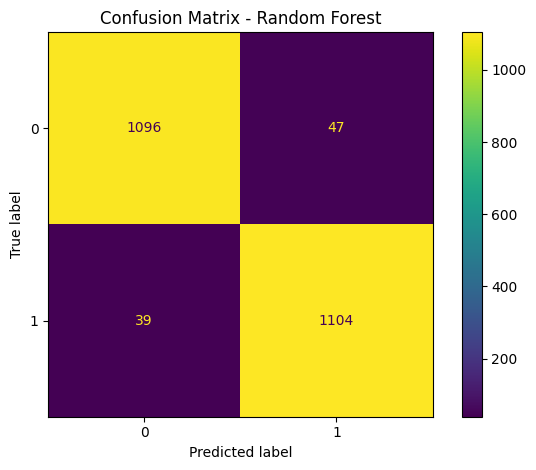

In [24]:
# Continue the downstream analysis with Random Forest (the paper's main model),
# regardless of which model scored highest on F1.
selected_model_name = "Random Forest"
selected_y_pred = predictions[selected_model_name]

print("Model used for downstream analysis:", selected_model_name)
print(classification_report(y_test, selected_y_pred))

cm = confusion_matrix(y_test, selected_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix - {selected_model_name}")
plt.tight_layout()
plt.show()

## 17. ROC and Precision–Recall Curves

These threshold-independent curves give a fuller picture of the best model than a single confusion matrix.

- **ROC-AUC** summarises the trade-off between true-positive rate and false-positive rate. It can look optimistic under class imbalance because it also rewards correct negatives.
- **PR-AUC (average precision)** focuses on the positive (phishing) class and is more informative when phishing is rare — the realistic deployment setting.

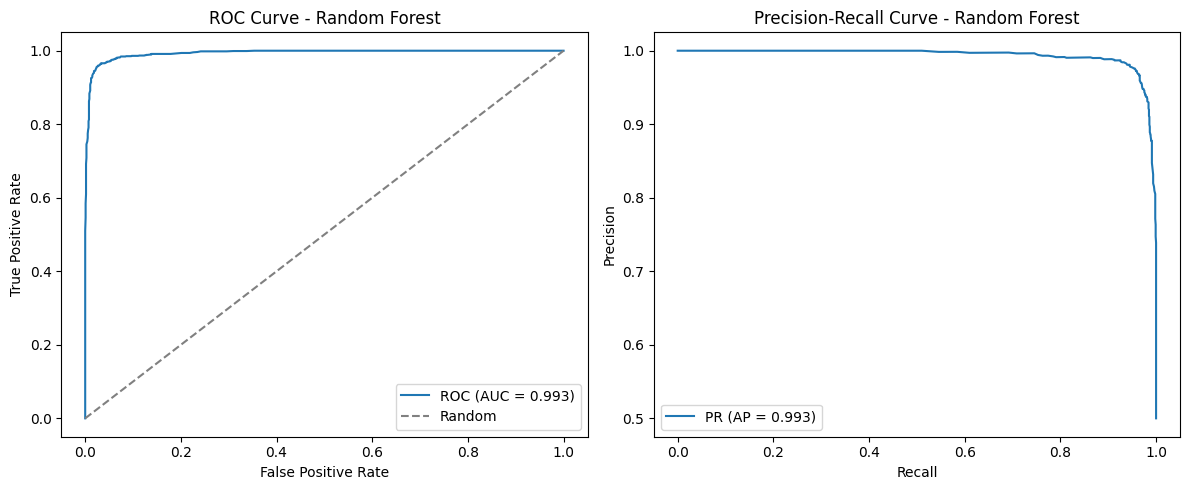

In [25]:
# The models in `models` were already fitted during training, so we reuse the selected one.
selected_model = models[selected_model_name]
y_score = selected_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc_value = auc(fpr, tpr)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_score)
avg_precision = average_precision_score(y_test, y_score)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label=f"ROC (AUC = {roc_auc_value:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"ROC Curve - {selected_model_name}")
axes[0].legend(loc="lower right")

axes[1].plot(recall_vals, precision_vals, label=f"PR (AP = {avg_precision:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"Precision-Recall Curve - {selected_model_name}")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

## 18. Feature Importance

Tree-based models can provide feature importance.  
This helps explain which features are most useful for phishing detection.

In [26]:
rf_model = models["Random Forest"]
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

feature_importance.head(20)

,feature,importance
79,google_index,0.190351
80,page_rank,0.104897
55,nb_hyperlinks,0.087612
77,web_traffic,0.078690
19,nb_www,0.039454
57,ratio_exthyperlinks,0.039089
76,domain_age,0.028607
45,longest_word_path,0.027039
56,ratio_inthyperlinks,0.024597
49,phish_hints,0.023501


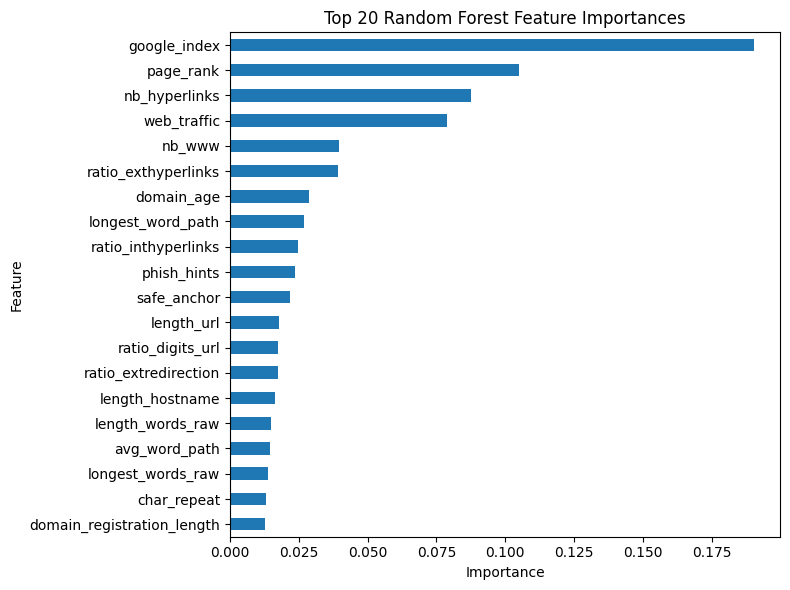

In [27]:
top_n = 20
feature_importance.head(top_n).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8, 6),
    legend=False,
)
plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 19. Feature Selection Experiment

Here we test whether a smaller set of important features can achieve similar performance.  
This helps evaluate the paper's feature-selection claim.

In [28]:
top_feature_counts = [10, 20, 30, 50]
feature_selection_results = []

for k in top_feature_counts:
    selected_features = feature_importance.head(k)["feature"].tolist()

    X_train_k = X_train[selected_features]
    X_test_k = X_test[selected_features]

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    metrics, _ = train_and_evaluate_model(
        f"Random Forest - Top {k} Features",
        model,
        X_train_k,
        X_test_k,
        y_train,
        y_test,
    )
    metrics["num_features"] = k
    feature_selection_results.append(metrics)

feature_selection_df = pd.DataFrame(feature_selection_results)
feature_selection_df[["model", "num_features", "accuracy", "precision", "recall", "f1", "f2", "roc_auc", "mcc"]]

,model,num_features,accuracy,precision,recall,f1,f2,roc_auc,mcc
0,Random Forest - Top 10 Features,10,0.952756,0.948052,0.958005,0.953003,0.955998,0.989672,0.905562
1,Random Forest - Top 20 Features,20,0.954506,0.949784,0.959755,0.954743,0.957744,0.990613,0.909061
2,Random Forest - Top 30 Features,30,0.957568,0.951641,0.964129,0.957844,0.961606,0.992386,0.915214
3,Random Forest - Top 50 Features,50,0.960630,0.955056,0.966754,0.960870,0.964392,0.993182,0.921329


## 20. Redundancy Removal Experiment

Here we remove highly correlated features and retrain the model.  
This checks whether redundant features are necessary.

In [29]:
X_reduced = X.drop(columns=features_to_drop_corr, errors="ignore")

print("Original number of features:", X.shape[1])
print("Reduced number of features:", X_reduced.shape[1])
print("Number of removed features:", X.shape[1] - X_reduced.shape[1])

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

rf_reduced = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

reduced_metrics, reduced_pred = train_and_evaluate_model(
    "Random Forest - Redundancy Removed",
    rf_reduced,
    X_train_red,
    X_test_red,
    y_train_red,
    y_test_red,
)

pd.DataFrame([reduced_metrics])

Original number of features: 81
Reduced number of features: 80
Number of removed features: 1


,accuracy,precision,recall,f1,f2,mcc,roc_auc,model
0,0.963692,0.96087,0.966754,0.963803,0.965571,0.927401,0.993538,Random Forest - Redundancy Removed


## 21. Suspicious Feature Removal Experiment

Some features depend on external services or blacklists (e.g. `statistical_report`, `web_traffic`, `google_index`, `page_rank`). These can leak label information or be unavailable in real-time detection, which inflates offline accuracy.
This experiment removes them and checks whether the model still performs well under more realistic conditions.

In [30]:
# External-service and blacklist features that may act as near-labels
# or require slow external lookups unavailable in real-time detection.
suspicious_features = [
    "statistical_report",   # checks phishing blacklists -- nearly encodes the label
    "web_traffic",          # requires external Alexa/traffic lookup
    "google_index",         # requires live Google query
    "page_rank",            # requires external PageRank lookup
]

existing_suspicious_features = [
    col for col in suspicious_features if col in X.columns
]

print("Suspicious features found and removed:", existing_suspicious_features)

X_without_suspicious = X.drop(columns=existing_suspicious_features, errors="ignore")

X_train_ws, X_test_ws, y_train_ws, y_test_ws = train_test_split(
    X_without_suspicious,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

rf_without_suspicious = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

metrics_ws, y_pred_ws = train_and_evaluate_model(
    "Random Forest - Without Suspicious Features",
    rf_without_suspicious,
    X_train_ws,
    X_test_ws,
    y_train_ws,
    y_test_ws
)

pd.DataFrame([metrics_ws])

Suspicious features found and removed: ['statistical_report', 'web_traffic', 'google_index', 'page_rank']


,accuracy,precision,recall,f1,f2,mcc,roc_auc,model
0,0.955818,0.954625,0.95713,0.955876,0.956628,0.911639,0.987876,Random Forest - Without Suspicious Features


## 22. Realistic Class Imbalance Simulation

The dataset is balanced, but real-world phishing detection is usually imbalanced.  
This optional experiment creates a more realistic test set with fewer phishing examples.

In [31]:
def create_imbalanced_test_set(
    X_test: pd.DataFrame,
    y_test: np.ndarray,
    positive_fraction: float = 0.05,
    random_state: int = 42,
) -> tuple[pd.DataFrame, np.ndarray]:
    """
    Create an imbalanced test set where positive class = phishing.
    Keeps all available negatives and downsamples positives to reach the requested prevalence.
    """
    rng = np.random.default_rng(random_state)

    y_series = pd.Series(y_test, index=X_test.index)

    positive_indices = y_series[y_series == 1].index.to_numpy()  # phishing
    negative_indices = y_series[y_series == 0].index.to_numpy()  # legitimate

    n_negatives = len(negative_indices)
    n_positives_needed = int(n_negatives * positive_fraction / (1 - positive_fraction))
    n_positives = min(n_positives_needed, len(positive_indices))

    selected_positives = rng.choice(
        positive_indices,
        size=n_positives,
        replace=False
    )

    selected_indices = np.concatenate([negative_indices, selected_positives])
    rng.shuffle(selected_indices)

    X_imbalanced = X_test.loc[selected_indices]
    y_imbalanced = y_series.loc[selected_indices].to_numpy()

    print("Created class distribution:")
    print(pd.Series(y_imbalanced).value_counts(normalize=True).sort_index())

    return X_imbalanced, y_imbalanced


X_test_imb, y_test_imb = create_imbalanced_test_set(
    X_test,
    y_test,
    positive_fraction=0.05,
    random_state=RANDOM_STATE,
)

# Reuse the Random Forest already fitted in section 15 instead of retraining it.
best_model = models["Random Forest"]

y_pred_imb = best_model.predict(X_test_imb)

if hasattr(best_model, "predict_proba"):
    y_score_imb = best_model.predict_proba(X_test_imb)[:, 1]
else:
    y_score_imb = None

imbalance_metrics = evaluate_predictions(y_test_imb, y_pred_imb, y_score_imb)
pd.DataFrame([imbalance_metrics])

Created class distribution:
0    0.950125
1    0.049875
Name: proportion, dtype: float64


,accuracy,precision,recall,f1,f2,mcc,roc_auc
0,0.959268,0.552381,0.966667,0.70303,0.84058,0.713841,0.992461


## 23. Error Analysis

We inspect false positives and false negatives.

- **False Positive:** legitimate website classified as phishing.
- **False Negative:** phishing website classified as legitimate.

In cybersecurity, false negatives are often more dangerous because attacks are missed.  
False positives are also important because they create usability issues and alert fatigue.

In [32]:
error_analysis_df = X_test.copy()
error_analysis_df["true_label"] = y_test
error_analysis_df["predicted_label"] = selected_y_pred

false_positives = error_analysis_df[
    (error_analysis_df["true_label"] == 0) & (error_analysis_df["predicted_label"] == 1)
]

false_negatives = error_analysis_df[
    (error_analysis_df["true_label"] == 1) & (error_analysis_df["predicted_label"] == 0)
]

print("False positives:", false_positives.shape[0])
print("False negatives:", false_negatives.shape[0])

False positives: 47
False negatives: 39


In [33]:
# Compare feature means for correctly detected phishing vs missed phishing.
true_positives = error_analysis_df[
    (error_analysis_df["true_label"] == 1) & (error_analysis_df["predicted_label"] == 1)
]

if false_negatives.shape[0] > 0:
    comparison = pd.DataFrame({
        "true_positive_mean": true_positives.drop(columns=["true_label", "predicted_label"]).mean(),
        "false_negative_mean": false_negatives.drop(columns=["true_label", "predicted_label"]).mean(),
    })
    comparison["absolute_difference"] = (
        comparison["true_positive_mean"] - comparison["false_negative_mean"]
    ).abs()

    display(comparison.sort_values("absolute_difference", ascending=False).head(20))
else:
    print("No false negatives found for the best model.")

,true_positive_mean,false_negative_mean,absolute_difference
web_traffic,934104.000906,664336.461538,269767.539367
domain_age,2990.000906,2466.256410,523.744496
nb_hyperlinks,29.479167,116.076923,86.597756
domain_registration_length,371.314312,446.282051,74.967740
length_url,77.130435,36.179487,40.950948
links_in_tags,44.702707,66.877306,22.174599
ratio_intmedia,34.079975,53.142883,19.062908
ratio_extmedia,17.459881,34.036604,16.576724
longest_word_path,16.877717,3.897436,12.980281
safe_anchor,31.834218,41.787573,9.953354


## 24. Cross-Validation Check

Cross-validation gives a more stable estimate than a single train/test split.

In [34]:
cv_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

cv_scores = cross_validate(
    cv_model,
    X,
    y,
    cv=5,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1,
)

cv_summary = pd.DataFrame(cv_scores).agg(["mean", "std"]).T
cv_summary

,mean,std
fit_time,1.289966,0.069627
score_time,0.070467,0.012029
test_accuracy,0.965792,0.002343
test_precision,0.966218,0.004578
test_recall,0.965354,0.000998
test_f1,0.965781,0.002266
test_roc_auc,0.993614,0.000818


## 25. Article Experiment I Extension: Pairwise Feature-Group Combinations

The original feature-group experiment evaluates each feature class individually and all features together. The article also evaluates combinations of feature classes. This section extends Experiment I by testing pairwise combinations:

- URL + Content
- URL + External-service
- Content + External-service
- All Features

This makes the notebook more directly aligned with the article's first experiment. Each feature-group combination is evaluated with five models — Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost — instead of Random Forest alone, so the comparison also shows which model architecture benefits most from which feature group.

In [35]:
# Instead of hardcoding the feature lists, we read them from the paper's own
# feature-extraction script. That script builds the dataset as
#     headers = url_headers + ctn_headers + tpt_headers
# so these three list literals are the authoritative source of each group.
def parse_header_groups(script_path: Path) -> Dict[str, List[str]]:
    """Return each feature group exactly as the dataset was generated.

    Parses (does not execute) the extractor script and pulls the three header
    list literals, normalising names the same way clean_column_names() did.
    """
    group_vars = {
        "url_headers": "URL-like Features",
        "ctn_headers": "Content-like Features",
        "tpt_headers": "External-service-like Features",
    }
    tree = ast.parse(script_path.read_text())
    raw = {}
    for node in ast.walk(tree):
        if isinstance(node, ast.Assign) and isinstance(node.value, (ast.List, ast.Tuple)):
            for target in node.targets:
                if isinstance(target, ast.Name) and target.id in group_vars:
                    raw[target.id] = [
                        elt.value for elt in node.value.elts
                        if isinstance(elt, ast.Constant) and isinstance(elt.value, str)
                    ]
    normalise = lambda s: s.strip().lower().replace(' ', '_').replace('-', '_').replace('.', '_')
    return {group_vars[var]: [normalise(name) for name in names] for var, names in raw.items()}


SCRIPT_PATH = Path("../data/scripts/feature_extractor.py")
parsed_groups = parse_header_groups(SCRIPT_PATH)

# Keep only the columns that survived cleaning (constant / duplicate removal).
feature_groups = {
    name: [c for c in cols if c in X.columns]
    for name, cols in parsed_groups.items()
}
feature_groups["All Features"] = X.columns.tolist()

# Sanity check: every surviving column should fall into exactly one parsed group.
assigned = set().union(*parsed_groups.values())
uncategorized = [c for c in X.columns if c not in assigned]
print("Groups parsed from:", SCRIPT_PATH)
print("Uncategorized features:", uncategorized)

for group_name, group_features in feature_groups.items():
    print(group_name, ":", len(group_features))

Groups parsed from: ../data/scripts/feature_extractor.py
Uncategorized features: []
Content-like Features : 19
URL-like Features : 55
External-service-like Features : 7
All Features : 81


In [36]:


# Robustly detect the feature group keys produced by the previous cell.
group_key_map = {}
for key in feature_groups.keys():
    lower_key = key.lower()
    if "url" in lower_key and "url" not in group_key_map:
        group_key_map["url"] = key
    elif "content" in lower_key and "content" not in group_key_map:
        group_key_map["content"] = key
    elif "external" in lower_key and "external" not in group_key_map:
        group_key_map["external"] = key

missing = [name for name in ["url", "content", "external"] if name not in group_key_map]
if missing:
    raise ValueError(f"Missing feature groups: {missing}. Available groups: {list(feature_groups.keys())}")

url_features = [col for col in feature_groups[group_key_map["url"]] if col in X.columns]
content_features = [col for col in feature_groups[group_key_map["content"]] if col in X.columns]
external_features = [col for col in feature_groups[group_key_map["external"]] if col in X.columns]

feature_group_combinations = {
    "URL only": url_features,
    "Content only": content_features,
    "External only": external_features,
    "URL + Content": sorted(set(url_features + content_features)),
    "URL + External": sorted(set(url_features + external_features)),
    "Content + External": sorted(set(content_features + external_features)),
    "All Features": X.columns.tolist(),
}


def build_combination_models() -> Dict[str, object]:
    """Fresh, unfitted model instances so each feature-group combination starts clean."""
    return {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
        ]),
        "Decision Tree": DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            max_depth=None,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
        ]),
        "Naive Bayes": GaussianNB(),
        "XGBoost": XGBClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=6,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=-1,
        ),
    }


feature_group_combination_results = []

for group_name, cols in feature_group_combinations.items():
    cols = [col for col in cols if col in X.columns]

    for model_name, model in build_combination_models().items():
        metrics, _ = train_and_evaluate_model(
            f"{model_name} - {group_name}",
            model,
            X_train[cols],
            X_test[cols],
            y_train,
            y_test,
        )

        metrics["feature_group"] = group_name
        metrics["num_features"] = len(cols)
        metrics["base_model"] = model_name
        feature_group_combination_results.append(metrics)

feature_group_combination_df = pd.DataFrame(feature_group_combination_results)
feature_group_combination_df = feature_group_combination_df[
    ["base_model", "feature_group", "num_features", "accuracy", "precision", "recall", "f1", "f2", "roc_auc", "mcc"]
].sort_values(["feature_group", "f1"], ascending=[True, False])

feature_group_combination_df

,base_model,feature_group,num_features,accuracy,precision,recall,f1,f2,roc_auc,mcc
41,XGBoost,All Features,81,0.966754,0.964317,0.969379,0.966841,0.968362,0.994170,0.933521
38,Random Forest,All Features,81,0.962380,0.959166,0.965879,0.962511,0.964529,0.993409,0.924782
39,SVM,All Features,81,0.954068,0.957672,0.950131,0.953887,0.951630,0.988306,0.908165
36,Logistic Regression,All Features,81,0.936133,0.939207,0.932633,0.935909,0.933941,0.981422,0.872287
37,Decision Tree,All Features,81,0.935696,0.935315,0.936133,0.935724,0.935969,0.935696,0.871391
40,Naive Bayes,All Features,81,0.742782,0.692042,0.874891,0.772798,0.830979,0.805094,0.503455
35,XGBoost,Content + External,26,0.951444,0.952632,0.950131,0.951380,0.950630,0.983726,0.902890
32,Random Forest,Content + External,26,0.947507,0.948291,0.946632,0.947461,0.946963,0.986768,0.895014
31,Decision Tree,Content + External,26,0.925197,0.920415,0.930884,0.925620,0.928771,0.925197,0.850449
33,SVM,Content + External,26,0.923885,0.923885,0.923885,0.923885,0.923885,0.970545,0.847769


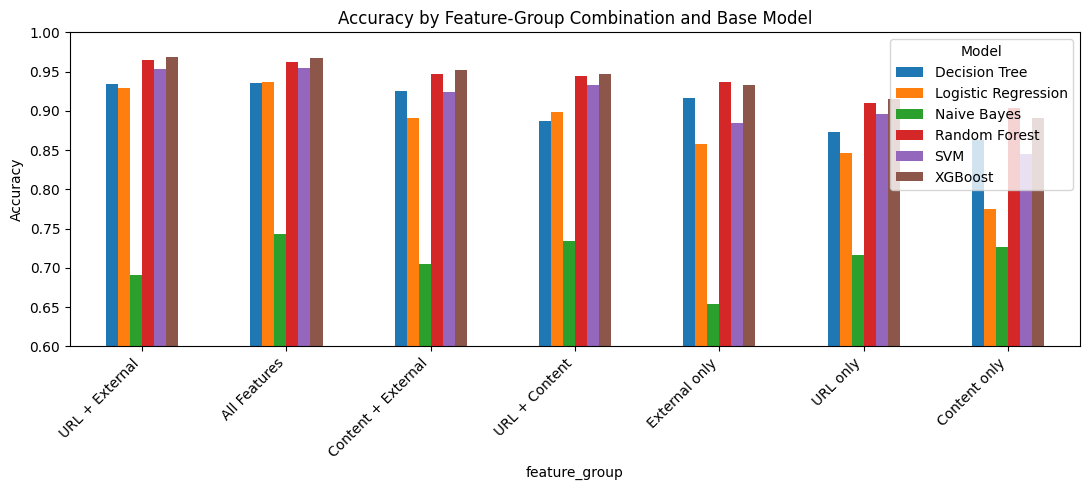

In [37]:
# Plot the pairwise feature-group combination results, grouped by base model.
plot_pivot = feature_group_combination_df.pivot(index="feature_group", columns="base_model", values="accuracy")
plot_pivot = plot_pivot.loc[
    feature_group_combination_df.groupby("feature_group")["accuracy"].max().sort_values(ascending=False).index
]

plot_pivot.plot(kind="bar", figsize=(11, 5))
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Accuracy by Feature-Group Combination and Base Model")
plt.ylim(0.60, 1.0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

### Interpretation: Experiment I Extension

This experiment completes the article-aligned feature-group analysis by adding pairwise feature combinations. The key comparison is whether `URL + External` or `All Features` performs better than each individual feature class. If the best result comes from `All Features` or `URL + External`, this supports the article's claim that hybrid feature sets are stronger than individual feature groups.

Because each combination is now tested with five base models, this also shows whether the hybrid-feature advantage holds regardless of model architecture, or whether it is specific to tree-based ensembles.

## 26. Article Experiment II: Combining Feature-Class Models

The article's second experiment tests whether separate models trained on different feature classes can be combined to improve performance. This notebook reproduces that idea by training one model per feature class (URL-based, content-based, external-service-based) and repeats the whole experiment for five base-model architectures — Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost.

Each base model's three feature-class predictions are combined using AND, OR, majority voting, and stacking. The purpose is to compare these combinations against a single model trained on all features, and to see whether the best combination strategy depends on the underlying model architecture.

In [38]:
# ------------------------------------------------------------
# Article Experiment II: Combining Feature-Class Models
# ------------------------------------------------------------

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict


def build_base_template(model_name: str):
    """Fresh, unfitted estimator for the given base-model type."""
    if model_name == "Logistic Regression":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
        ])
    if model_name == "Decision Tree":
        return DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=None)
    if model_name == "Random Forest":
        return RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    if model_name == "SVM":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
        ])
    if model_name == "Naive Bayes":
        return GaussianNB()
    if model_name == "XGBoost":
        return XGBClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=6,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=-1,
        )
    raise ValueError(f"Unknown base model: {model_name}")


def run_experiment_ii(base_model_name: str) -> pd.DataFrame:
    """Train one base model per feature class, combine predictions, and score each combination rule."""
    base_template = build_base_template(base_model_name)

    model_url = clone(base_template)
    model_content = clone(base_template)
    model_external = clone(base_template)

    model_url.fit(X_train[url_features], y_train)
    model_content.fit(X_train[content_features], y_train)
    model_external.fit(X_train[external_features], y_train)

    # Test-set predictions and probabilities from each feature-class model.
    pred_url = model_url.predict(X_test[url_features])
    pred_content = model_content.predict(X_test[content_features])
    pred_external = model_external.predict(X_test[external_features])

    proba_url = model_url.predict_proba(X_test[url_features])[:, 1]
    proba_content = model_content.predict_proba(X_test[content_features])[:, 1]
    proba_external = model_external.predict_proba(X_test[external_features])[:, 1]

    base_predictions = np.vstack([pred_url, pred_content, pred_external]).T
    base_probabilities = np.vstack([proba_url, proba_content, proba_external]).T

    # Combination rules from the article.
    pred_and = (base_predictions.sum(axis=1) == 3).astype(int)      # phishing only if all models say phishing
    pred_or = (base_predictions.sum(axis=1) >= 1).astype(int)       # phishing if any model says phishing
    pred_majority = (base_predictions.sum(axis=1) >= 2).astype(int) # phishing if at least two models agree
    score_mean_proba = base_probabilities.mean(axis=1)

    # Stacking with out-of-fold training predictions to reduce optimistic bias.
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    oof_url = cross_val_predict(
        clone(base_template), X_train[url_features], y_train, cv=cv, method="predict_proba", n_jobs=-1
    )[:, 1]
    oof_content = cross_val_predict(
        clone(base_template), X_train[content_features], y_train, cv=cv, method="predict_proba", n_jobs=-1
    )[:, 1]
    oof_external = cross_val_predict(
        clone(base_template), X_train[external_features], y_train, cv=cv, method="predict_proba", n_jobs=-1
    )[:, 1]

    X_train_stack = np.vstack([oof_url, oof_content, oof_external]).T
    X_test_stack = base_probabilities

    stacking_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    stacking_model.fit(X_train_stack, y_train)

    pred_stacking = stacking_model.predict(X_test_stack)
    score_stacking = stacking_model.predict_proba(X_test_stack)[:, 1]

    combination_outputs = {
        "AND combination": (pred_and, score_mean_proba),
        "OR combination": (pred_or, score_mean_proba),
        "Majority voting": (pred_majority, score_mean_proba),
        "Stacking": (pred_stacking, score_stacking),
    }

    results = []
    for method_name, (pred, score) in combination_outputs.items():
        metrics = evaluate_predictions(y_test, pred, score)
        metrics["combination_method"] = method_name
        metrics["base_model"] = base_model_name
        results.append(metrics)

    return pd.DataFrame(results)


experiment_ii_df = pd.concat(
    [run_experiment_ii(name) for name in ["Logistic Regression", "Decision Tree", "Random Forest", "SVM", "Naive Bayes", "XGBoost"]],
    ignore_index=True,
)
experiment_ii_df = experiment_ii_df[
    ["base_model", "combination_method", "accuracy", "precision", "recall", "f1", "f2", "roc_auc", "mcc"]
].sort_values(["base_model", "accuracy"], ascending=[True, False])

experiment_ii_df

,base_model,combination_method,accuracy,precision,recall,f1,f2,roc_auc,mcc
7,Decision Tree,Stacking,0.940070,0.935121,0.945757,0.940409,0.943610,0.977728,0.880197
6,Decision Tree,Majority voting,0.939633,0.934313,0.945757,0.940000,0.943446,0.975748,0.879331
4,Decision Tree,AND combination,0.872266,0.987400,0.754156,0.855159,0.791552,0.975748,0.766216
5,Decision Tree,OR combination,0.840332,0.761074,0.992126,0.861375,0.935335,0.975748,0.714381
3,Logistic Regression,Stacking,0.924759,0.920346,0.930009,0.925152,0.928060,0.975958,0.849566
2,Logistic Regression,Majority voting,0.904199,0.889545,0.923010,0.905968,0.916117,0.975332,0.808972
0,Logistic Regression,AND combination,0.803150,0.977931,0.620297,0.759101,0.669247,0.975332,0.651423
1,Logistic Regression,OR combination,0.772528,0.691929,0.982502,0.812003,0.906376,0.975332,0.600582
19,Naive Bayes,Stacking,0.804462,0.796928,0.817148,0.806911,0.813022,0.893960,0.609120
18,Naive Bayes,Majority voting,0.774278,0.769561,0.783027,0.776236,0.780296,0.892423,0.548640


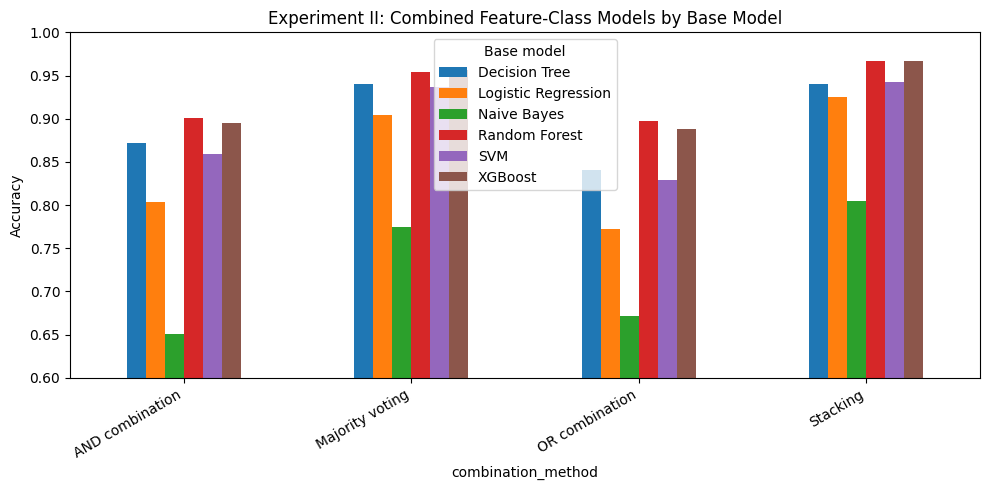

In [39]:
# Plot Experiment II results, grouped by base model.
plot_pivot = experiment_ii_df.pivot(index="combination_method", columns="base_model", values="accuracy")

plot_pivot.plot(kind="bar", figsize=(10, 5))
plt.xticks(rotation=30, ha="right")
plt.ylabel("Accuracy")
plt.title("Experiment II: Combined Feature-Class Models by Base Model")
plt.ylim(0.60, 1.0)
plt.legend(title="Base model")
plt.tight_layout()
plt.show()

### Interpretation: Experiment II

This experiment evaluates whether combining specialized feature-class models improves over a single model trained on all features. If majority voting or stacking does not outperform the corresponding all-feature model, the result supports the article's conclusion that model-combination strategies do not necessarily improve over the best hybrid-feature model. Comparing across base-model architectures also shows whether any stacking/voting gains are consistent or specific to a particular model type.

## Article Experiment Alignment Summary

The notebook now aligns more closely with the article's experimental structure:

- **Experiment I** was enhanced by adding pairwise feature-group combinations.
- **Experiment II** was added by combining separate URL, content, and external-service models using AND, OR, majority voting, and stacking.

The notebook still keeps the critical extensions required for the assignment, including XGBoost comparison, richer cybersecurity metrics, class-imbalance simulation, and error analysis.

## 27. Save Results

This creates CSV files that can be used in the final report.

In [40]:
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
feature_importance.to_csv(RESULTS_DIR / "feature_importance.csv", index=False)
feature_selection_df.to_csv(RESULTS_DIR / "feature_selection_results.csv", index=False)

# Persist the additional experiment metrics for the report.
if "reduced_metrics" in globals():
    pd.DataFrame([reduced_metrics]).to_csv(RESULTS_DIR / "redundancy_removed_metrics.csv", index=False)

if "metrics_ws" in globals():
    pd.DataFrame([metrics_ws]).to_csv(RESULTS_DIR / "suspicious_removed_metrics.csv", index=False)

if "imbalance_metrics" in globals():
    pd.DataFrame([imbalance_metrics]).to_csv(RESULTS_DIR / "imbalance_metrics.csv", index=False)

if "feature_group_combination_df" in globals() and not feature_group_combination_df.empty:
    feature_group_combination_df.to_csv(RESULTS_DIR / "feature_group_combination_results.csv", index=False)

if "experiment_ii_df" in globals() and not experiment_ii_df.empty:
    experiment_ii_df.to_csv(RESULTS_DIR / "experiment_ii_model_combination_results.csv", index=False)


print("Results saved to:", RESULTS_DIR)

Results saved to: ../results


## 28. Critical Evaluation Notes for the Report

Observations below are grounded in the actual numbers produced by this run (see `../results/*.csv`).

### Paper claim 1: Random Forest is the strongest classifier
**Verdict: partially supported.**

| Model | F1 | MCC | ROC-AUC | Accuracy |
|---|---|---|---|---|
| Random Forest | 0.9625 | 0.9248 | 0.9934 | 96.24% |
| XGBoost | 0.9668 | 0.9335 | 0.9942 | 96.68% |
| SVM | 0.9539 | 0.9082 | 0.9883 | 95.41% |
| Logistic Regression | 0.9359 | 0.8723 | 0.9814 | 93.61% |
| Decision Tree | 0.9357 | 0.8714 | 0.9357 | 93.57% |
| Naive Bayes | 0.7728 | 0.5035 | 0.8051 | 74.28% |

Among the models the paper actually compared, RF wins on every metric — that part of the claim holds cleanly. But XGBoost (added as an extension) quietly beats RF on all four metrics. This isn't a contradiction of the paper so much as a sign the paper's model selection was incomplete: ensembles of trees generally win, RF just wasn't the *best possible* one. Naive Bayes trailing badly (MCC 0.50, barely better than a coin flip) makes sense given its independence assumption — many of the 81 features (e.g. URL length and hostname length) are correlated, which directly violates what Naive Bayes needs to work well.

### Paper claim 2: Hybrid (all) features perform best
**Verdict: supported, but with an important caveat.**

| Feature group | # features | F1 | Accuracy |
|---|---|---|---|
| All features | 81 | 0.9625 | 96.24% |
| External-service only | 7 | 0.9368 | 93.66% |
| URL only | 55 | 0.9104 | 90.99% |
| Content only | 19 | 0.9039 | 90.42% |

The full feature set wins, so the headline claim holds. The caveat is about what a reader might assume: it's tempting to say "URL features are good enough for real-time detection since you don't need to fetch the page." The numbers say otherwise — URL-only loses almost 6 accuracy points versus the full model, which is a meaningful gap in a security context. What's more interesting is that external-service features alone (just 7 of them!) get within ~2.6 points of the full 81-feature model. That's a much stronger "lightweight alternative" story than URL-only is.

There's a workaround, though: Experiment II shows that if you train three separate models (one per feature group) and **stack** their outputs, you recover full-model performance (F1 0.9664) while still being able to compute the three feature groups independently or in parallel. That's a more defensible "efficient" architecture than just dropping to URL-only features.

### Paper claim 3: External-service features are highly discriminative
**Verdict: strongly supported.**

The top 3 individual feature importances are *all* external-service features:
- `google_index` — 0.190
- `page_rank` — 0.105
- `web_traffic` — 0.079

Together that's over 35% of the Random Forest's total importance concentrated in just 3 of 81 features. This lines up with the feature-group result above: a model using only 7 external-service features (F1 0.937) beats a model using 55 URL features (F1 0.910), despite having ~8x fewer inputs.

The known limitation — that these features require a live network call to Google/third-party services, so they're slow, rate-limited, or simply unavailable at inference time — is real, but it can be quantified: dropping the "suspicious"/near-label features drops F1 from 0.9625 to 0.9559 (MCC from 0.9248 to 0.9116). That's only about a 0.7-point F1 loss — small enough to say the model has a credible fallback mode that doesn't depend on external services, even though those services are individually the single best predictors.

### Dataset limitation
**Verdict: confirmed empirically, not just asserted.**

The dataset used here is artificially balanced (~50/50 phishing vs. legitimate), which doesn't reflect reality — phishing sites are a small minority of all web traffic. Simulating a realistic imbalanced test set produces the textbook "accuracy paradox":

- Accuracy stayed high: **95.9%**
- Precision collapsed: **0.55**
- F1 dropped to: **0.70**

In plain terms: a model that looks like it's 96% correct is actually only right about half the time when it *flags* something as phishing, once phishing becomes rare. This is exactly why the report should lead with precision/recall/F1/MCC, not accuracy — accuracy alone would have hidden this problem entirely.

### Two findings beyond what the assignment template asked for
- **Redundancy removal didn't hurt — it slightly helped** (F1 0.9638 vs. 0.9625 baseline). Several of the 81 raw features are likely redundant, so a leaner feature set is not just faster, it's marginally more accurate too.
- **Feature count can be cut drastically with minimal cost**: a 10-feature RF model still reaches F1 0.953 — under 1 point below the 81-feature model. That's a strong, data-backed argument for a lightweight production detector instead of computing all 81 features per request.

### Security interpretation
False negatives (missed phishing) and false positives (blocking legitimate sites) have very different costs, and the AND/OR ensemble results from Experiment II give concrete numbers to reason about that trade-off:
- **AND combination** (require all sub-models to agree): precision 0.992, recall 0.807 — very few false alarms, but ~19% of phishing slips through. Good for a low-friction UX where you only act when very confident.
- **OR combination** (any sub-model triggers): precision 0.833, recall 0.993 — catches almost everything, but more false alarms. Good for high-security contexts like an enterprise email gateway, where missing phishing is far more costly than annoying a user.
- **Stacking** sits in between and actually wins on both F1 (0.966) and MCC (0.933) — the best single deployable choice if you can't offer a tunable threshold.

## 29. Final Conclusion

The reproduced experiments support the paper's central claim: machine-learning models trained on URL, content, and external-service features detect phishing websites effectively. Random Forest (F1 0.963, MCC 0.925, ROC-AUC 0.993) matches the paper's reported strength, and a modern XGBoost model (F1 0.967, MCC 0.934, ROC-AUC 0.994) slightly exceeds it. The hybrid feature set outperforms any single feature group, confirming the value of combining URL, content, and especially external-service signals — external-service features alone, using just 7 of 81 attributes, account for the top three individual feature importances and reach 93.7% accuracy by themselves.

Three findings complicate a straightforward "the paper is correct, deploy as-is" reading:

1. **Accuracy is misleading under realistic class imbalance.** Simulating a realistic phishing-minority prevalence collapsed precision from ~0.96 to 0.55 even though accuracy stayed near 96%. The paper's balanced-dataset accuracy figures overstate real-world precision; any production system must be evaluated under realistic prevalence using precision/F1/MCC, not benchmark accuracy.
2. **Dependence on external-service features is real but not absolute.** Removing the "suspicious"/near-label features (`google_index`, `page_rank`, `web_traffic`) costs only ~0.7 F1 points, so a fallback model without live external lookups remains viable when those services are slow, rate-limited, or unavailable — an important consideration for real-time detection.
3. **Far fewer features are needed in practice.** A 10-feature Random Forest reaches F1 0.953, within 1 point of the full 81-feature model, and stacking three independently-computed feature-group models (Experiment II) matches the full hybrid model's performance (F1 0.966) while allowing URL/content/external-service scoring to run in parallel or be selectively skipped.

**Overall:** the paper's claims about hybrid features and Random Forest's strength are reproducible and well-supported on this balanced benchmark, but a deployable system should (a) be evaluated under realistic class imbalance, (b) use MCC/F1/recall rather than accuracy as the primary metric, and (c) consider a leaner, redundancy-reduced or feature-group-stacked architecture to control latency and reduce dependence on third-party services. The AND/OR security trade-off (precision-favoring vs. recall-favoring) should be chosen deliberately based on whether false positives or false negatives are more costly for the specific deployment context.